# Polymarket Calibration Analysis

**Research question:** Are Polymarket prediction markets well calibrated?

A perfectly calibrated market means: markets trading at 70% odds should resolve YES ~70% of the time.
We test this claim across topics and find systematic mispricings.

**Pipeline overview:**
1. Fetch resolved markets from Polymarket Gamma + CLOB APIs
2. **Enrich missing category labels using zero-shot NLP** (BART-large-MNLI)
3. Calibration analysis: overall + by category
4. Biggest mispricings
5. Price convergence over market lifetime

**Data:** 375 resolved YES/NO markets (2023–2024), 16K daily price observations.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT))

from lib.backtest import brier_score, brier_skill_score, calibration_bins
from lib.data_utils import load_parquet, save_parquet

DATA_DIR  = Path().resolve().parent / "data"
PLOTS_DIR = Path().resolve().parent / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
PALETTE = sns.color_palette("tab10")

## 1. Load Data

In [2]:
markets = load_parquet(DATA_DIR / "markets.parquet")
prices  = load_parquet(DATA_DIR / "price_history.parquet")

print(f"Markets            : {len(markets):,}")
print(f"Price history rows : {len(prices):,}")
print(f"Markets with prices: {prices['market_id'].nunique():,}")
print()
print("Category coverage before enrichment:")
print(markets["category"].fillna("(missing)").value_counts().to_string())

Markets            : 375
Price history rows : 16,434
Markets with prices: 140

Category coverage before enrichment:
category
(missing)             343
US-current-affairs     18
Crypto                  6
Ukraine & Russia        4
Coronavirus             1
Global Politics         1
Pop-Culture             1
                        1


[Single Market] Will Joe Biden win the U.S. 2024 Democratic presidential nomination?
  Outcome: NO  |  587 obs  (2022-12-16 -> 2024-08-07)


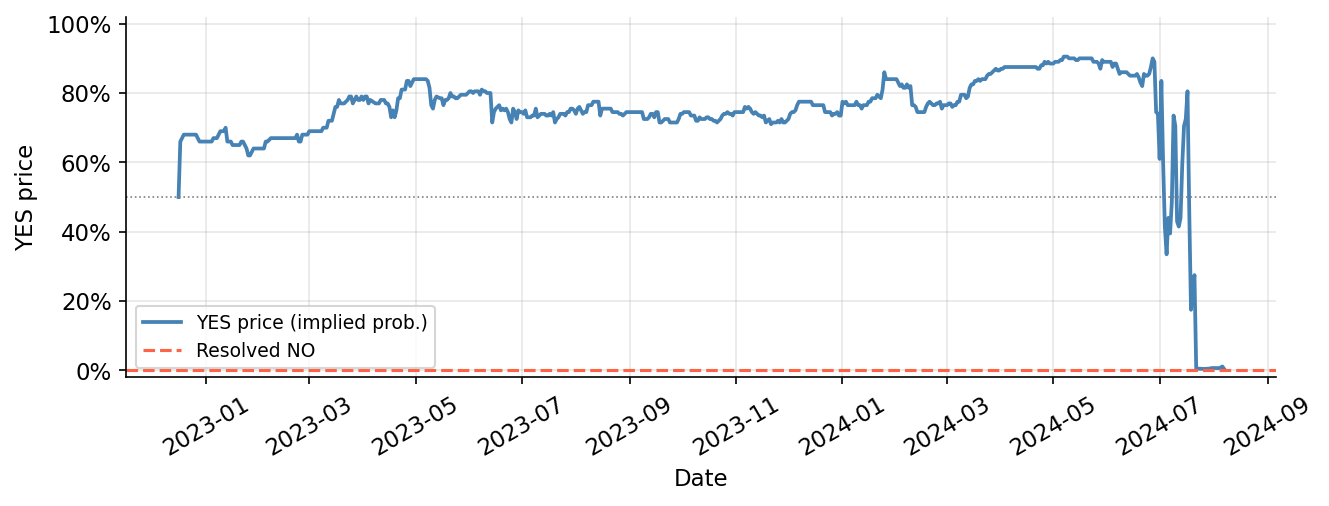

[Single Market] Will Kamala Harris win the U.S. 2024 Democratic presidential nomination?
  Outcome: YES  |  563 obs  (2023-01-10 -> 2024-08-07)


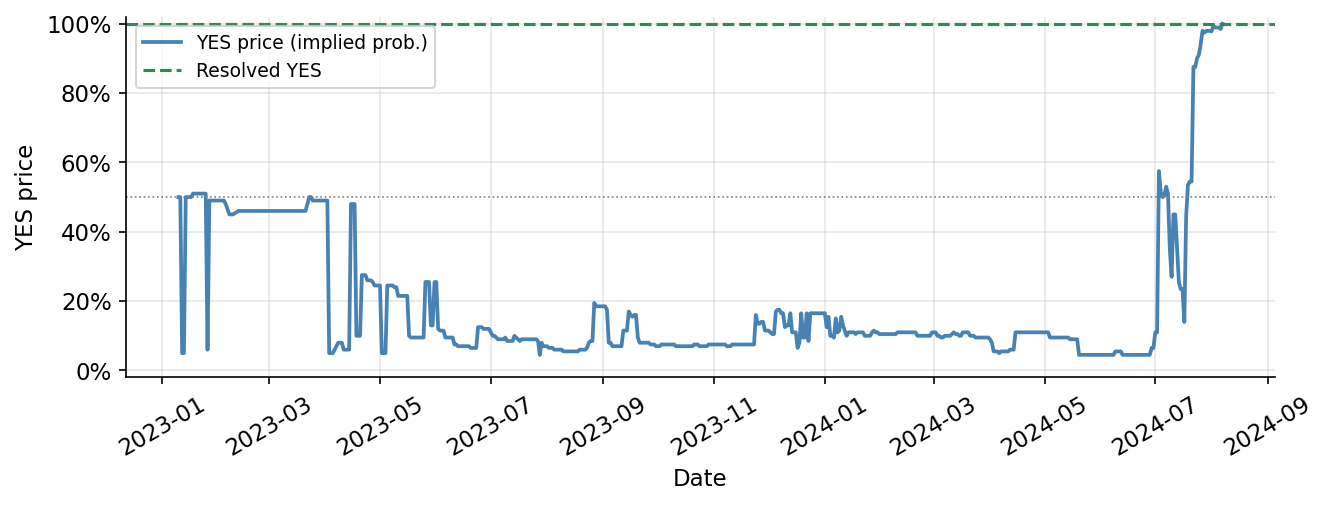

In [3]:
# Join price history with market metadata by market_id.
# For N example markets: print the question, then plot price evolution + resolution.
N = 2
example_ids = prices["market_id"].value_counts().head(N).index.tolist()


for mid in example_ids:
    mkt  = markets[markets["market_id"] == mid].iloc[0]
    path = prices[prices["market_id"] == mid].sort_values("timestamp")

    print(mkt["question"])
    print(f"  Outcome: {mkt['outcome']}  |  {len(path)} obs  "
          f"({path['timestamp'].min():%Y-%m-%d} -> {path['timestamp'].max():%Y-%m-%d})")

    resolved_yes = mkt["outcome"] == "YES"
    res_color = "seagreen" if resolved_yes else "tomato"

    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(path["timestamp"], path["price"], color="steelblue", lw=1.8,
            label="YES price (implied prob.)")
    ax.axhline(mkt["resolution_price"], color=res_color, lw=1.5, linestyle="--",
               label=f"Resolved {mkt['outcome']}")
    ax.axhline(0.5, color="grey", lw=0.8, linestyle=":")

    ax.set_xlabel("Date")
    ax.set_ylabel("YES price")
    ax.set_ylim(-0.02, 1.02)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="best", fontsize=9)

    fig.tight_layout()
    plt.show()

## 2. Categories via NLU (discover → inspect → name)

Polymarket only tags ~41% of markets, so we build the taxonomy **from the data**:

1. **Clean** each question of temporal/numeric noise (dates, months, `$`/`%`) so topics — not
   deadlines — drive the grouping.
2. **Embed** with `all-MiniLM-L6-v2` and **cluster** with K-Means (`k` by silhouette, interpretable
   range 4–10).
3. **Inspect** each cluster's top c-TF-IDF **keywords** + representative questions (the NLU step).
4. **Name** each cluster with **BART zero-shot**, feeding it real example questions from that
   cluster — a handful of model calls, one per cluster.
5. **Propagate** the cluster name to every market it contains.

> Key point: classification happens at the **cluster** level (≈9 BART calls), *not* per market.
> The clustering already assigns all 375 markets to a group, so running zero-shot on each question
> individually would be wasteful and would discard the structure we just found.

In [4]:
import re
from sentence_transformers import SentenceTransformer

# --- Strip temporal / numeric noise so embeddings cluster by TOPIC, not by date ---
# Without this, "by March 31, 2023" dominates and chess + Eurovision + elections end up together
# just because they share a month word.
MONTHS   = ("january|february|march|april|may|june|july|august|september|october|november|december"
            "|jan|feb|mar|apr|jun|jul|aug|sept|sep|oct|nov|dec")
WEEKDAYS = "monday|tuesday|wednesday|thursday|friday|saturday|sunday|weekend|week|day"

def strip_temporal(text: str) -> str:
    t = str(text).lower()
    t = re.sub(r"\d{1,2}[/-]\d{1,2}[/-]\d{2,4}", " ", t)   # 03/05/2023, 3-11-23
    t = re.sub(rf"\b({MONTHS})\b", " ", t)                 # month names
    t = re.sub(rf"\b({WEEKDAYS})\b", " ", t)               # weekday / week / day
    t = re.sub(r"\$?\d[\d,\.]*%?", " ", t)                 # numbers, $25, 0.5%, years
    t = re.sub(r"\s+", " ", t).strip()
    return t

clean_questions = markets["question"].fillna("").map(strip_temporal)

# Sanity check: see what the cleaning does
print("Cleaning examples:")
for q in markets["question"].head(3):
    print(f"  {q[:58]!r}\n   -> {strip_temporal(q)[:58]!r}")
print()

# Encode the CLEANED text into 384-dim semantic embeddings (all-MiniLM-L6-v2, CPU-friendly)
embedder = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")
embeddings = embedder.encode(
    clean_questions.tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,   # cosine geometry -> Euclidean KMeans behaves well
)
print(f"Embeddings: {embeddings.shape}")

Cleaning examples:
  '[Single Market] Will Ron DeSantis win the U.S. 2024 Republ'
   -> '[single market] will ron desantis win the u.s. republican '
  '[Single Market] Will Donald J. Trump win the U.S. 2024 Rep'
   -> '[single market] will donald j. trump win the u.s. republic'
  '[Single Market] Will Nikki Haley win the U.S. 2024 Republi'
   -> '[single market] will nikki haley win the u.s. republican p'



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Embeddings: (375, 384)


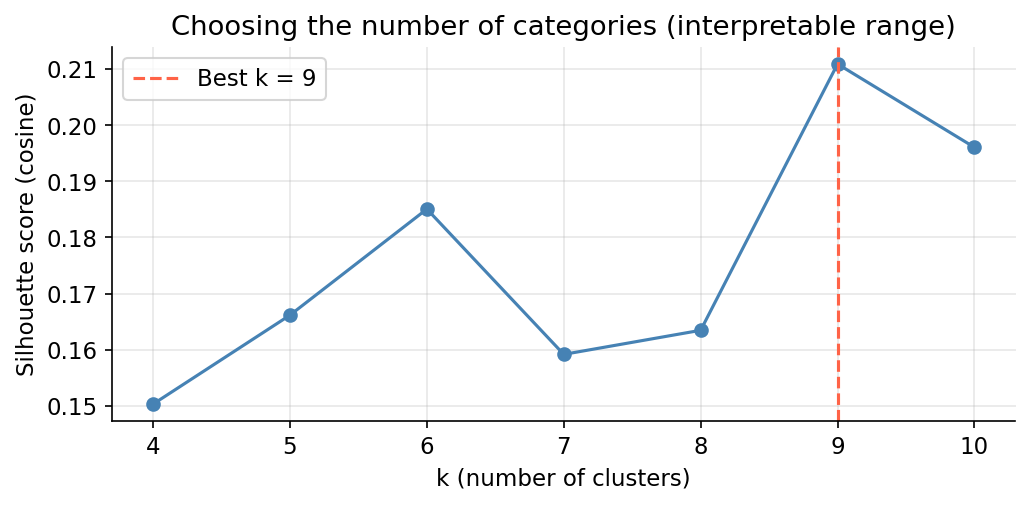

Selected k = 9  (silhouette = 0.211)


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# NOTE: silhouette keeps rising with k for short-text embeddings (tiny clusters are very compact),
# so its global argmax (~44 here) is NOT the right "number of human categories" -- it just makes
# micro-clusters. We restrict the search to an interpretable range and take the best k there.
k_range = range(4, 11)
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(embeddings)
    sil_scores.append(silhouette_score(embeddings, labels, metric="cosine"))

best_k = list(k_range)[int(np.argmax(sil_scores))]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(list(k_range), sil_scores, "-o", color="steelblue")
ax.axvline(best_k, color="tomato", linestyle="--", label=f"Best k = {best_k}")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette score (cosine)")
ax.set_title("Choosing the number of categories (interpretable range)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Selected k = {best_k}  (silhouette = {max(sil_scores):.3f})")

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Final clustering with the chosen k
km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
markets["cluster"] = km.fit_predict(embeddings)

# c-TF-IDF style labelling: treat each cluster as one "document" and rank words by TF-IDF.
# Use the SAME cleaned text the embeddings saw, plus domain stopwords so labels describe the
# TOPIC ("eagles, super bowl") rather than generic verbs ("win") or leftover time words.
DOMAIN_STOP = {
    "win", "wins", "winner", "beat", "market", "single", "reach", "fail",
    "gross", "greater", "did", "vs", "usa", "us", "team",
}
stop_words = list(ENGLISH_STOP_WORDS | DOMAIN_STOP)

cluster_docs = (
    pd.DataFrame({"cluster": markets["cluster"], "text": clean_questions})
    .groupby("cluster")["text"]
    .apply(lambda s: " ".join(s))
    .sort_index()
)
vec = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=2,
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b",   # alphabetic words only -> no numbers
)
tfidf = vec.fit_transform(cluster_docs)
terms = np.array(vec.get_feature_names_out())

cluster_keywords = {}
for c in range(best_k):
    row = tfidf[c].toarray().ravel()
    top = terms[row.argsort()[::-1][:6]]
    cluster_keywords[c] = list(top)

# Inspect each cluster: size, keywords, and representative questions (closest to centroid)
print(f"Discovered {best_k} clusters\n" + "=" * 70)
for c in range(best_k):
    members = markets[markets["cluster"] == c]
    # distance to centroid for representative examples
    idx = members.index.to_numpy()
    centroid = km.cluster_centers_[c]
    dist = np.linalg.norm(embeddings[idx] - centroid, axis=1)
    reps = members.iloc[np.argsort(dist)[:3]]["question"].tolist()

    print(f"\nCluster {c}  (n={len(members)})")
    print(f"  keywords : {', '.join(cluster_keywords[c])}")
    for q in reps:
        print(f"  - {q[:75]}")

Discovered 9 clusters

Cluster 0  (n=40)
  keywords : sbf, bail sbf, bail, insolvent, usdc, announce
  - Will the Fed increase interest rates by 0 bps after its February meeting?
  - Will the Fed increase interest rates by 75 bps after its February meeting?
  - Will the Fed increase interest rates by 50 bps after its February meeting?

Cluster 1  (n=52)
  keywords : city, united, west, man, season, record
  - Will Liverpool beat Bournemouth? (03/11/2023)
  - Will Chelsea beat Leeds? (03/04/2023)
  - Will Liverpool beat Manchester Utd? (03/05/2023)

Cluster 2  (n=87)
  keywords : presidential, biden, election, joe, joe biden, remain
  - Will Joe Biden be President of the United States on April 1, 2023?
  - Will Joe Biden be President of the United States on June 1, 2023?
  - Will Joe Biden be President of the USA on February 1, 2023?

Cluster 3  (n=31)
  keywords : st, usdc, ethereum, merge, new, bing
  - Will the price of $ETH be above $1700 on February 10?
  - Will the price of $ETH b

In [7]:
# --- Name each cluster with BART zero-shot (added ON TOP of the keyword analysis above) ---
# Clustering stays fully data-driven (how many groups, which questions). BART only assigns a
# clean, human-readable label to each cluster from a broad candidate pool, using the cluster's
# most representative questions.
#
# Specific, domain-flavoured labels discriminate far better than bare nouns: "Cryptocurrency and
# token prices" beats "Cryptocurrency" for the $ETH cluster, etc. This is the main lever for
# confidence -- tune it before touching the template.
from transformers import pipeline

CANDIDATE_LABELS = [
    "Politics and elections",
    "Soccer matches",
    "American football and the NFL",
    "Cryptocurrency and token prices",
    "Inflation and Federal Reserve interest rates",
    "Movie box office revenue",
    "Music, awards and entertainment",
    "Chess tournaments",
    "Social media and tweets",
    "Technology and AI",
]

# Reuse the zero-shot pipeline if it's already loaded (also used in section 2).
# NOTE: the hypothesis must be a fluent, grammatical sentence -- BART-MNLI was trained on natural
# NLI hypotheses, so a broken/over-long template ("This texts ... are about {}") wrecks entailment.
# Domain framing is fine as long as it stays grammatical and short.
if "classifier" not in globals():
    print("Loading BART-large-MNLI...")
    classifier = pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        device=-1,
        hypothesis_template="This prediction market question is about {}.",
    )

N_REPS = 10  # representative questions per cluster fed to the classifier
CLUSTER_NAMES, cluster_name_conf = {}, {}
for c in range(best_k):
    members = markets[markets["cluster"] == c]
    idx = members.index.to_numpy()
    dist = np.linalg.norm(embeddings[idx] - km.cluster_centers_[c], axis=1)
    reps = members.iloc[np.argsort(dist)[:N_REPS]]["question"].tolist()
    rep_text = " ".join(strip_temporal(q) for q in reps)

    out = classifier(rep_text, CANDIDATE_LABELS, multi_label=False)
    CLUSTER_NAMES[c]      = out["labels"][0]
    cluster_name_conf[c]  = out["scores"][0]
    print(f"Cluster {c} (n={len(members):>3}): {out['labels'][0]:33s} "
          f"(conf {out['scores'][0]:.2f})  | keywords: {', '.join(cluster_keywords[c][:4])}")

Loading BART-large-MNLI...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Cluster 0 (n= 40): Inflation and Federal Reserve interest rates (conf 0.71)  | keywords: sbf, bail sbf, bail, insolvent


Cluster 1 (n= 52): Soccer matches                    (conf 0.30)  | keywords: city, united, west, man


Cluster 2 (n= 87): Politics and elections            (conf 0.93)  | keywords: presidential, biden, election, joe


...

Cluster 4 (n= 27): Inflation and Federal Reserve interest rates (conf 0.40)  | keywords: launch, balloon, vladimir putin, west


Cluster 5 (n= 30): Movie box office revenue          (conf 0.65)  | keywords: million, western, man, west


Cluster 6 (n= 24): Social media and tweets           (conf 0.82)  | keywords: token, parlay, arbitrum, rihanna


Cluster 7 (n= 58): Chess tournaments                 (conf 0.82)  | keywords: presidential election, red, points, presidential


Cluster 8 (n= 26): American football and the NFL     (conf 0.68)  | keywords: rihanna, biden, qb, scoring


In [8]:
# Propagate each cluster's BART name to every market in it -> all 375 markets get a category,
# straight from the clustering. No per-market inference.
# Override a label by hand if you disagree, e.g. CLUSTER_NAMES[3] = "Cryptocurrency", then re-run.
markets["category_clean"] = markets["cluster"].map(CLUSTER_NAMES)

CATEGORIES = sorted(markets["category_clean"].unique())
print(f"Discovered taxonomy ({len(CATEGORIES)} categories):")
for c in CATEGORIES:
    print(f"  - {c:35s} (n={(markets['category_clean'] == c).sum()})")

Discovered taxonomy (8 categories):


  - American football and the NFL       (n=26)
  - Chess tournaments                   (n=58)
  - Cryptocurrency and token prices     (n=31)
  - Inflation and Federal Reserve interest rates (n=67)
  - Movie box office revenue            (n=30)
  - Politics and elections              (n=87)
  - Soccer matches                      (n=52)
  - Social media and tweets             (n=24)


### Persist labelled markets

Save the markets with their data-driven `category_clean` so the calibration analysis below can
load them directly.

In [9]:
# Persist labelled markets for the downstream calibration analysis
markets_enriched = markets.copy()
save_parquet(markets_enriched, DATA_DIR / "markets_enriched.parquet")
print(f"Saved {len(markets_enriched)} labelled markets -> data/markets_enriched.parquet")

Saved 375 labelled markets -> data/markets_enriched.parquet


### Design notes — what this pipeline had to get right

Building the taxonomy was iterative; the choices below each fix a concrete failure we hit:

1. **Discover, don't hardcode.** A hand-picked list of 7 categories was arbitrary and didn't match
   the data. We cluster the question embeddings instead and let the topics emerge.

2. **Strip temporal/numeric noise *before* embedding.** First attempt clustered by **date**:
   chess, Eurovision and elections landed together just for sharing "March 2023". Removing dates,
   months, weekdays and `$`/`%` amounts (`strip_temporal`) made the clusters topical.

3. **Don't trust the silhouette argmax.** On short-text embeddings silhouette keeps rising with `k`
   (it rewarded `k≈44` micro-clusters). We restrict `k` to an interpretable range (4–10).

4. **Clean the keyword labels.** Numbers and generic verbs ("win", "beat") dominated the c-TF-IDF
   keywords. We drop non-alphabetic tokens and add domain stopwords so keywords describe the topic.

5. **Name at the cluster level, not per market.** The clustering already assigns *all 375 markets*
   to a group, so we run BART zero-shot ~9 times (once per cluster on representative questions)
   instead of 375 times. Cheaper and consistent — and it reuses the structure we just found.

6. **BART-MNLI needs a grammatical hypothesis.** A broken template
   (`"This texts extracted from polimarket are about {}"`) collapsed confidence and mislabelled the
   crypto and inflation clusters as *Politics*. A fluent template
   (`"This prediction market question is about {}."`) restored it.

7. **Specific candidate labels beat bare nouns.** `"Cryptocurrency and token prices"` /
   `"Inflation and Federal Reserve interest rates"` discriminate better than one-word labels —
   the main lever for naming confidence.

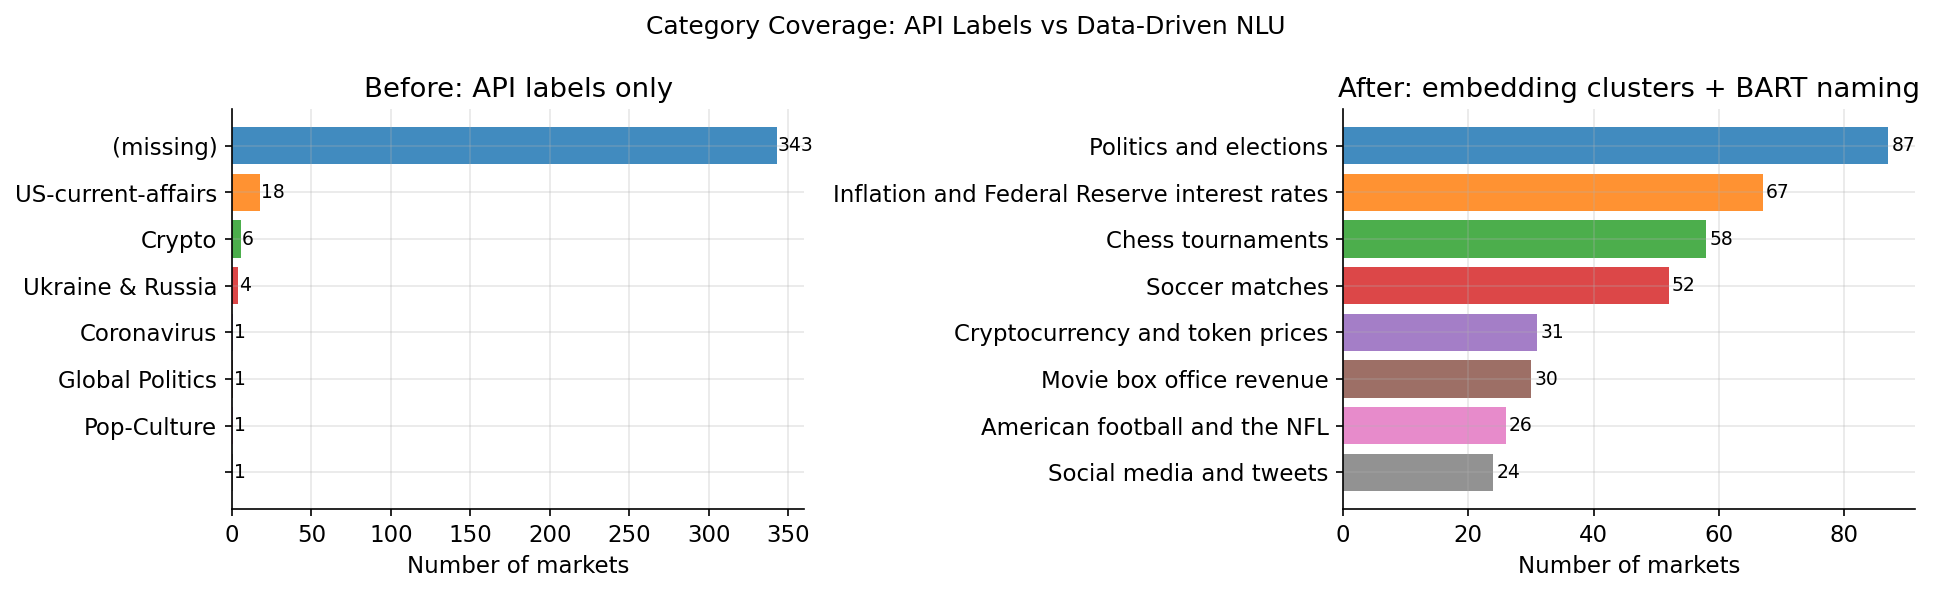

In [10]:
# Category coverage: sparse API labels vs the data-driven taxonomy
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

before = markets["category"].fillna("(missing)").str.strip().value_counts()
after  = markets_enriched["category_clean"].value_counts()

for ax, counts, title in [
    (axes[0], before, "Before: API labels only"),
    (axes[1], after,  "After: embedding clusters + BART naming"),
]:
    colors = PALETTE[:len(counts)]
    bars = ax.barh(counts.index[::-1], counts.values[::-1], color=colors[::-1], alpha=0.85)
    ax.set_xlabel("Number of markets")
    ax.set_title(title)
    for bar, val in zip(bars, counts.values[::-1]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=9)

fig.suptitle("Category Coverage: API Labels vs Data-Driven NLU", fontsize=12)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "00_category_enrichment.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Prepare Analysis Dataset

In [11]:
# Load enriched markets (avoids re-running model if notebook is re-executed)
markets_enriched = load_parquet(DATA_DIR / "markets_enriched.parquet")

# Per-market price stats
def market_price_stats(prices: pd.DataFrame) -> pd.DataFrame:
    out = []
    for mid, grp in prices.sort_values("timestamp").groupby("market_id"):
        p = grp["price"].values
        out.append({
            "market_id":   mid,
            "final_odds":  p[-1],
            "avg_odds":    p.mean(),
            "median_odds": np.median(p),
            "n_days":      len(p),
            "odds_std":    p.std(),
        })
    return pd.DataFrame(out)

price_stats = market_price_stats(prices)

df = markets_enriched.merge(price_stats, on="market_id", how="inner")
df["y"] = (df["outcome"] == "YES").astype(int)

print(f"Analysis dataset : {len(df):,} markets with price history")
print(f"YES: {df['y'].sum()} ({df['y'].mean():.1%})   NO: {(1-df['y']).sum()} ({(1-df['y']).mean():.1%})")
print()
print(df["category_clean"].value_counts().to_string())

Analysis dataset : 140 markets with price history
YES: 43 (30.7%)   NO: 97 (69.3%)

category_clean
Politics and elections                          48
Chess tournaments                               33
Inflation and Federal Reserve interest rates    23
Cryptocurrency and token prices                  9
American football and the NFL                    9
Soccer matches                                   8
Social media and tweets                          6
Movie box office revenue                         4


## 4. Overall Calibration

We bin markets by their **final-day implied probability** and compare against the actual resolution rate.
A perfectly calibrated market lies on the diagonal (dotted line).
Bubble size encodes the number of markets in each bin.

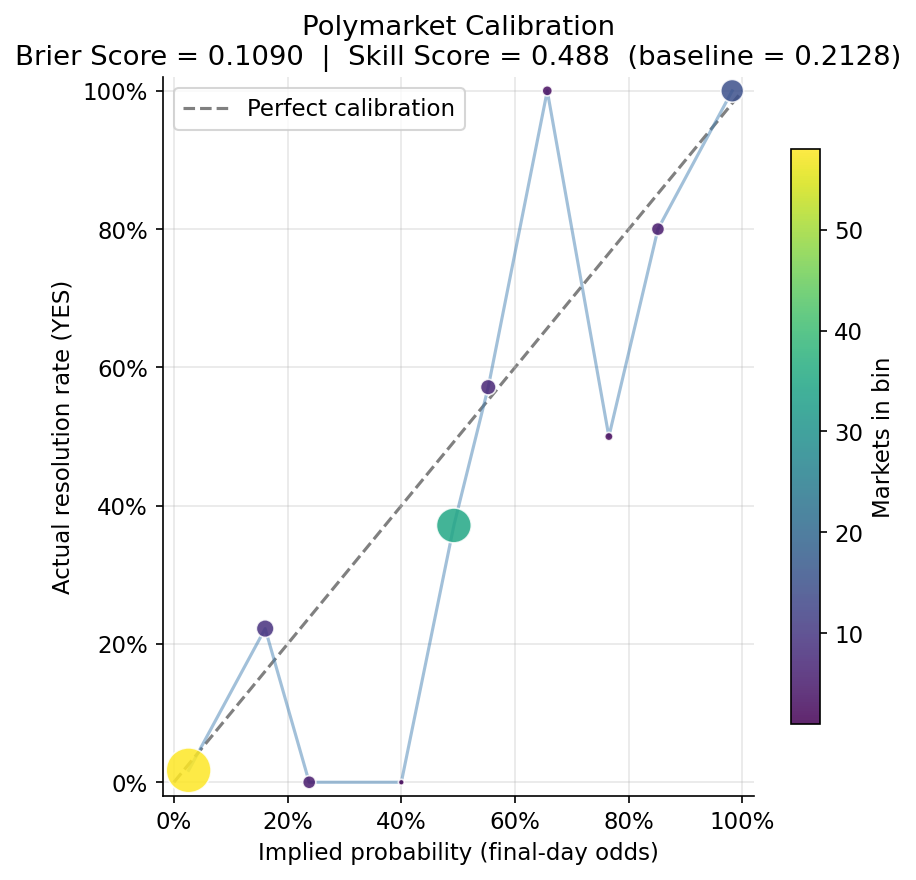

In [12]:
calib = calibration_bins(df["y"].values, df["final_odds"].values, n_bins=10)

bs  = brier_score(df["y"].values, df["final_odds"].values)
bss = brier_skill_score(df["y"].values, df["final_odds"].values)
bs_baseline = brier_score(df["y"].values, np.full(len(df), df["y"].mean()))

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot([0, 1], [0, 1], "--", color="grey", lw=1.5, label="Perfect calibration", zorder=1)

valid = calib.dropna(subset=["mean_forecast", "actual_rate"])
sc = ax.scatter(
    valid["mean_forecast"], valid["actual_rate"],
    s=valid["count"] * 8, alpha=0.85, zorder=3,
    c=valid["count"], cmap="viridis", edgecolors="white", linewidths=0.8,
)
ax.plot(valid["mean_forecast"], valid["actual_rate"],
        "-", color="steelblue", lw=1.5, zorder=2, alpha=0.5)

plt.colorbar(sc, ax=ax, label="Markets in bin", shrink=0.8)

ax.set_xlabel("Implied probability (final-day odds)")
ax.set_ylabel("Actual resolution rate (YES)")
ax.set_title(
    f"Polymarket Calibration\n"
    f"Brier Score = {bs:.4f}  |  Skill Score = {bss:.3f}  "
    f"(baseline = {bs_baseline:.4f})"
)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.tight_layout()
fig.savefig(PLOTS_DIR / "01_calibration_overall.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Calibration by Category

With enriched categories we can now ask: do some topics produce better-calibrated markets?

In [13]:
MIN_N = 5
valid_cats = df["category_clean"].value_counts()
valid_cats = valid_cats[valid_cats >= MIN_N].index.tolist()

cat_stats = []
for cat in valid_cats:
    sub = df[df["category_clean"] == cat]
    cat_stats.append({
        "category":      cat,
        "n_markets":     len(sub),
        "yes_rate":      sub["y"].mean(),
        "brier_score":   brier_score(sub["y"].values, sub["final_odds"].values),
        "brier_skill":   brier_skill_score(sub["y"].values, sub["final_odds"].values),
        "mean_final_odds": sub["final_odds"].mean(),
    })

cat_df = pd.DataFrame(cat_stats).sort_values("brier_score")
cat_df.round(4)

,category,n_markets,yes_rate,brier_score,brier_skill,mean_final_odds
6,Social media and tweets,6,0.1667,0.0116,0.9164,0.2208
3,Cryptocurrency and token prices,9,0.3333,0.0277,0.8752,0.4128
0,Politics and elections,48,0.3125,0.0818,0.6193,0.2664
5,Soccer matches,8,0.3750,0.1036,0.5581,0.4394
1,Chess tournaments,33,0.3030,0.1307,0.3811,0.3930
4,American football and the NFL,9,0.2222,0.1359,0.2135,0.2933
2,Inflation and Federal Reserve interest rates,23,0.3043,0.1733,0.1814,0.3742


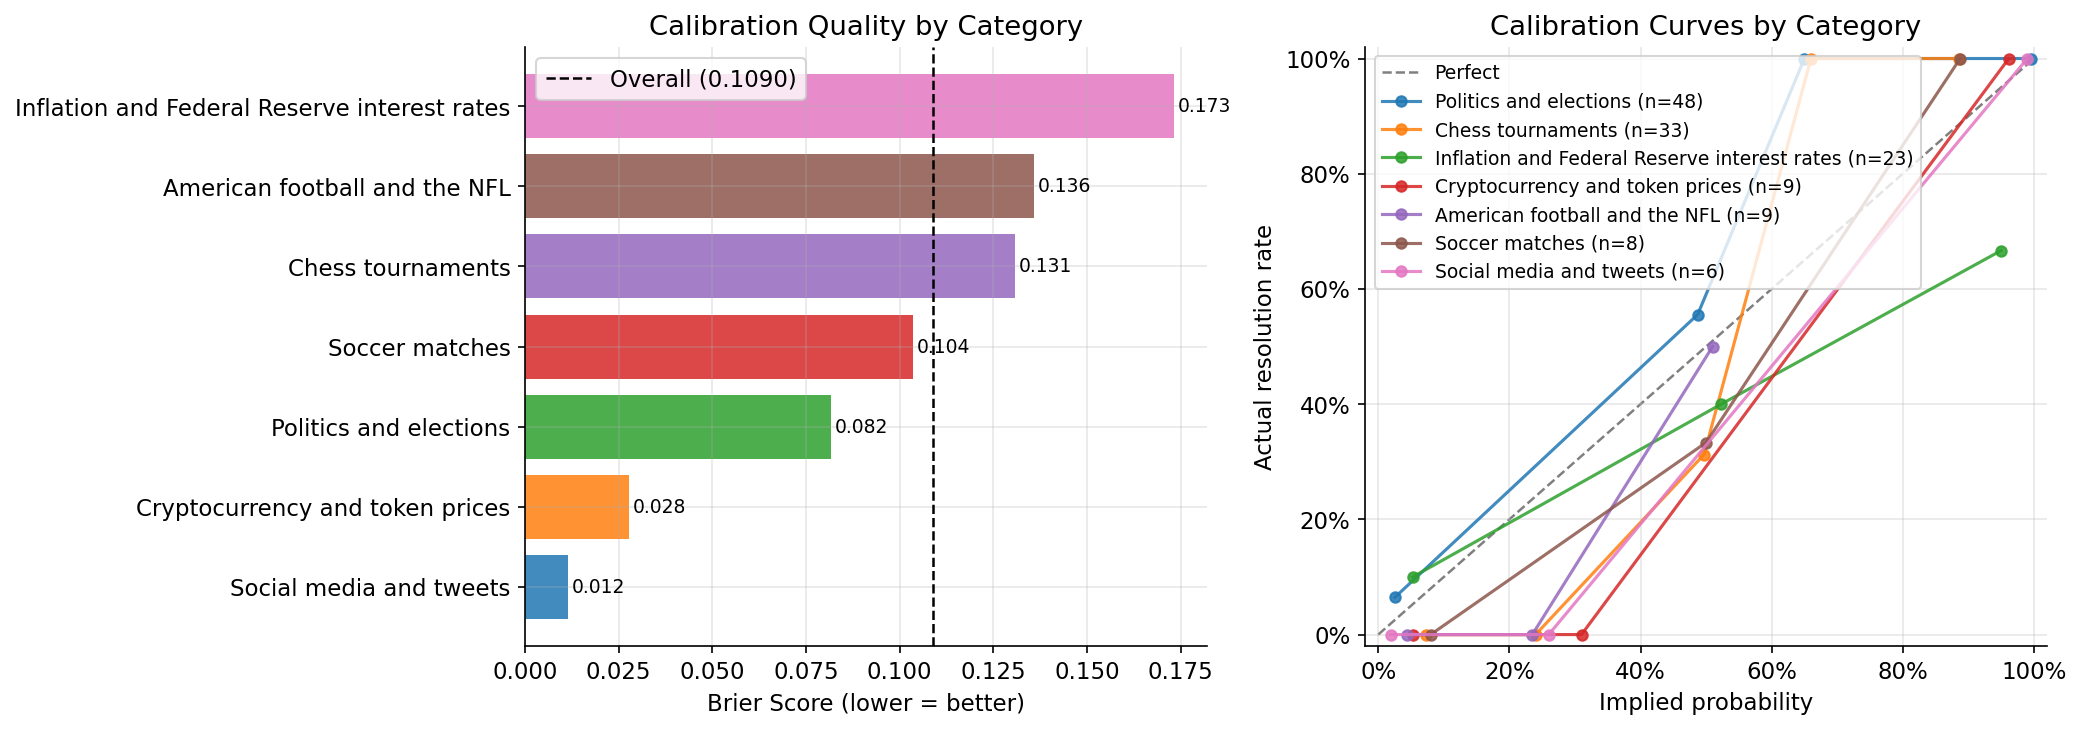

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Brier score bar chart
ax = axes[0]
colors = [PALETTE[i % 10] for i in range(len(cat_df))]
bars = ax.barh(cat_df["category"], cat_df["brier_score"], color=colors, alpha=0.85)
ax.axvline(bs, color="black", lw=1.2, linestyle="--", label=f"Overall ({bs:.4f})")
ax.set_xlabel("Brier Score (lower = better)")
ax.set_title("Calibration Quality by Category")
ax.legend()
for bar, val in zip(bars, cat_df["brier_score"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

# Right: calibration curves
ax = axes[1]
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1.2, zorder=1, label="Perfect")
for i, cat in enumerate(valid_cats):
    sub = df[df["category_clean"] == cat]
    cb  = calibration_bins(sub["y"].values, sub["final_odds"].values, n_bins=5)
    cb  = cb.dropna(subset=["mean_forecast", "actual_rate"])
    if len(cb) < 2:
        continue
    ax.plot(cb["mean_forecast"], cb["actual_rate"],
            "-o", color=PALETTE[i % 10], ms=5, lw=1.5,
            label=f"{cat} (n={len(sub)})", alpha=0.85)

ax.set_xlabel("Implied probability")
ax.set_ylabel("Actual resolution rate")
ax.set_title("Calibration Curves by Category")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=9, loc="upper left")

fig.tight_layout()
fig.savefig(PLOTS_DIR / "02_calibration_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Biggest Mispricings

Which markets had the largest gap between implied probability and actual outcome?

- **Positive error** (red): market overestimated YES probability → resolved NO
- **Negative error** (blue): market underestimated YES probability → resolved YES

In [15]:
df["error"]     = df["final_odds"] - df["y"]
df["abs_error"] = df["error"].abs()

top_n = 10
cols  = ["question", "category_clean", "final_odds", "outcome", "error", "volume_usd"]

top_mispriced = df.nlargest(top_n, "abs_error")[cols].copy()
top_mispriced["final_odds"] = top_mispriced["final_odds"].map("{:.1%}".format)
top_mispriced["error"]      = top_mispriced["error"].map("{:+.2f}".format)
top_mispriced["volume_usd"] = top_mispriced["volume_usd"].map("${:,.0f}".format)
top_mispriced["question"]   = top_mispriced["question"].str[:65]
print(top_mispriced.to_string(index=False))

                                                         question                               category_clean final_odds outcome error volume_usd
              Will Donald J. Trump be indicted by March 31, 2023?                       Politics and elections       6.0%     YES -0.94   $874,177
Will U.S. inflation be greater than 0.1% from February to March 2 Inflation and Federal Reserve interest rates      90.0%      NO +0.90     $1,812
            Will the "Chinese spy balloon" be down by February 5? Inflation and Federal Reserve interest rates      15.0%     YES -0.85    $29,226
                   Will Hunter Biden be indicted by July 1, 2023?                       Politics and elections      16.5%     YES -0.83    $58,215
Golden Globes: Will "Everything Everywhere All At Once" win Best                      Movie box office revenue      75.0%      NO +0.75       $178
Will U.S. inflation be greater than 0.2% from February to March 2 Inflation and Federal Reserve interest rates      57

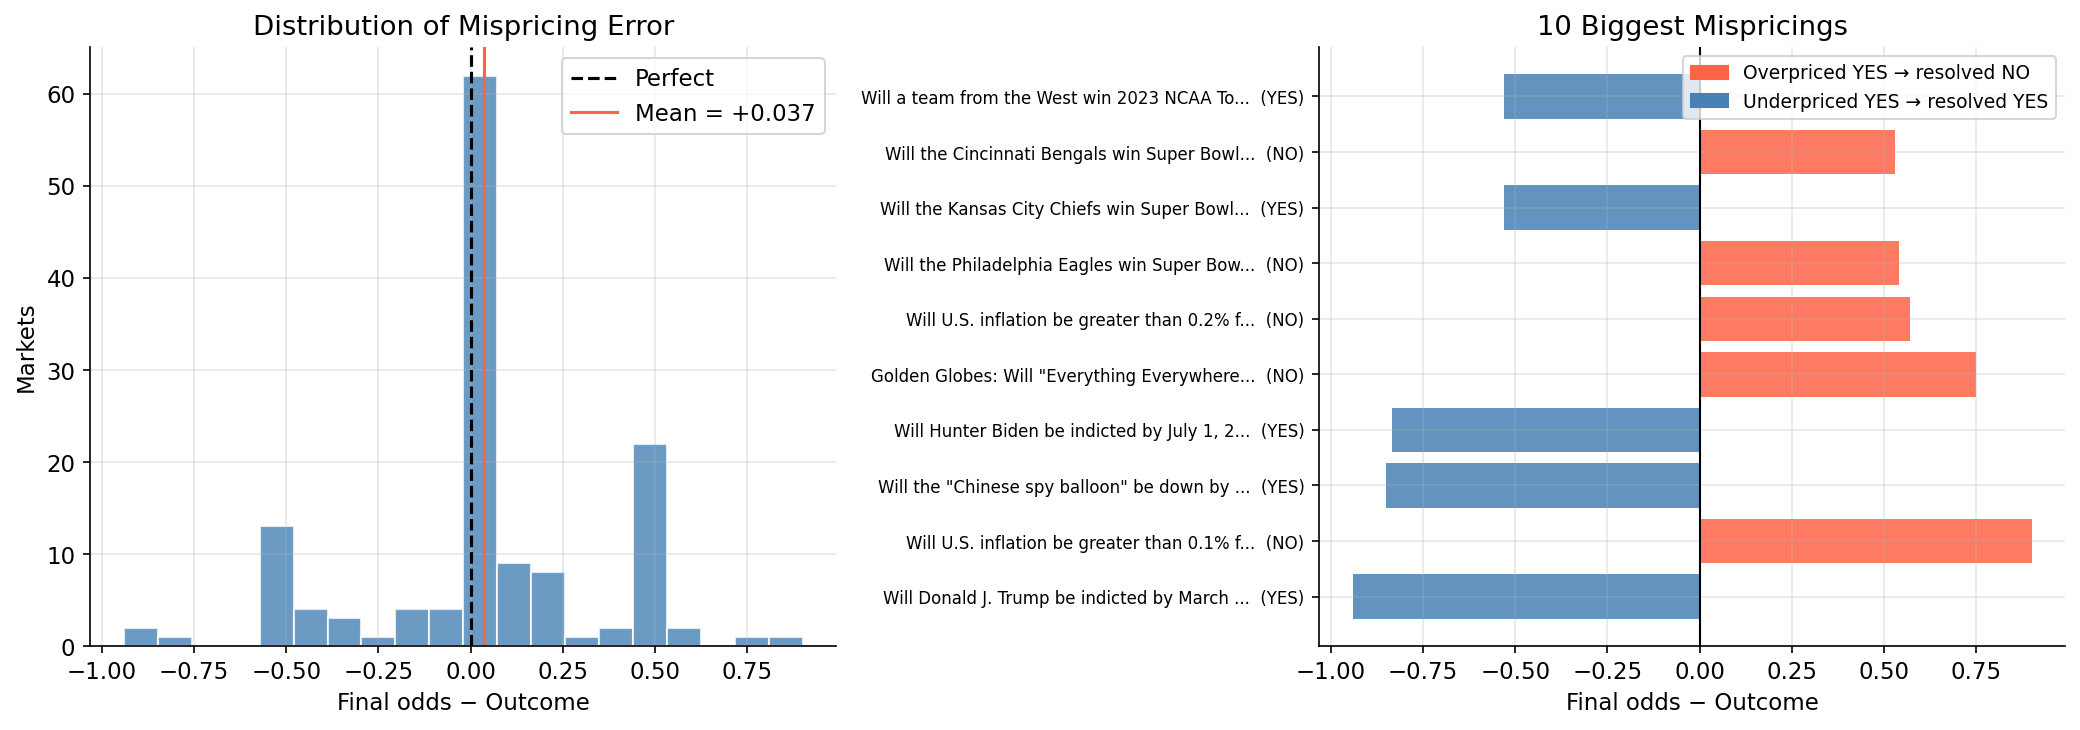

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df["error"], bins=20, color="steelblue", alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", lw=1.5, linestyle="--", label="Perfect")
ax.axvline(df["error"].mean(), color="tomato", lw=1.5,
           label=f"Mean = {df['error'].mean():+.3f}")
ax.set_xlabel("Final odds − Outcome")
ax.set_ylabel("Markets")
ax.set_title("Distribution of Mispricing Error")
ax.legend()

ax = axes[1]
worst = df.nlargest(top_n, "abs_error").copy()
worst["label"] = worst["question"].str[:42] + "...  (" + worst["outcome"] + ")"
colors = ["tomato" if e > 0 else "steelblue" for e in worst["error"]]
ax.barh(range(len(worst)), worst["error"], color=colors, alpha=0.85)
ax.set_yticks(range(len(worst)))
ax.set_yticklabels(worst["label"], fontsize=8)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Final odds − Outcome")
ax.set_title("10 Biggest Mispricings")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="tomato",    label="Overpriced YES → resolved NO"),
    Patch(color="steelblue", label="Underpriced YES → resolved YES"),
], fontsize=9)

fig.tight_layout()
fig.savefig(PLOTS_DIR / "03_mispricings.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Price Convergence Over Market Lifetime

We normalize each market's timeline to [0, 1] (fraction of lifetime elapsed)
and plot YES-price paths grouped by resolution.
This reveals whether markets start well-calibrated or converge only at the end.

In [17]:
norm_paths = []
for mid, grp in prices.sort_values("timestamp").groupby("market_id"):
    meta = df[df["market_id"] == mid]
    if meta.empty or len(grp) < 3:
        continue
    norm_paths.append({
        "market_id": mid,
        "outcome":   meta["y"].iloc[0],
        "category":  meta["category_clean"].iloc[0],
        "t": np.linspace(0, 1, len(grp)),
        "p": grp["price"].values,
    })

print(f"Markets with normalized paths: {len(norm_paths)}")

Markets with normalized paths: 134


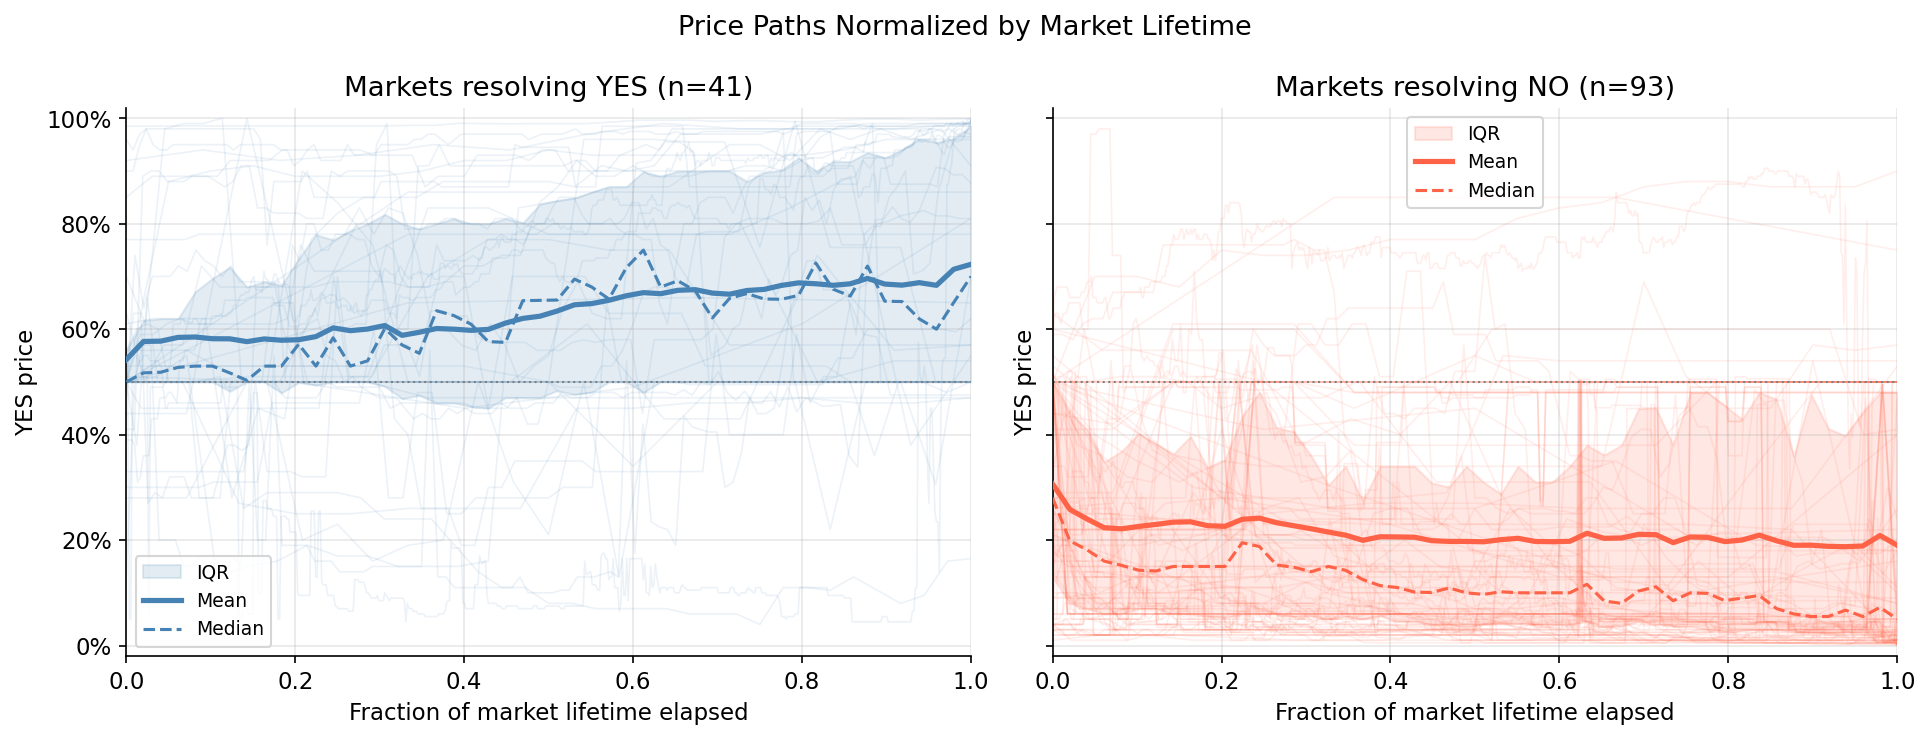

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
t_grid = np.linspace(0, 1, 50)

for ax, label, color, title in [
    (axes[0], 1, "steelblue", "Markets resolving YES"),
    (axes[1], 0, "tomato",    "Markets resolving NO"),
]:
    subset = [p for p in norm_paths if p["outcome"] == label]
    for path in subset:
        ax.plot(path["t"], path["p"], color=color, alpha=0.10, lw=0.8)

    if subset:
        mat = np.array([np.interp(t_grid, p["t"], p["p"]) for p in subset])
        ax.fill_between(t_grid, np.percentile(mat, 25, axis=0),
                        np.percentile(mat, 75, axis=0), color=color, alpha=0.15, label="IQR")
        ax.plot(t_grid, mat.mean(axis=0),           color=color, lw=2.5, label="Mean",   zorder=3)
        ax.plot(t_grid, np.median(mat, axis=0), "--", color=color, lw=1.5, label="Median", zorder=3)

    ax.axhline(0.5, color="grey", lw=1, linestyle=":")
    ax.set_xlabel("Fraction of market lifetime elapsed")
    ax.set_ylabel("YES price")
    ax.set_title(f"{title} (n={len(subset)})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=9)

fig.suptitle("Price Paths Normalized by Market Lifetime", fontsize=13)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "04_price_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Summary & Key Findings

In [19]:
best_cat  = cat_df.iloc[0]
worst_cat = cat_df.iloc[-1]
worst_mkt = df.nlargest(1, "abs_error").iloc[0]

print("=" * 65)
print("KEY FINDINGS")
print("=" * 65)
print(f"Dataset              : {len(df):,} resolved binary markets with price history")
print(f"Date range           : 2023-01-01 to 2024-09-10")
print()
print(f"Taxonomy             : {len(CATEGORIES)} categories discovered via NLU")
print(f"                       (text embeddings + K-Means, clusters named by BART zero-shot)")
print()
print(f"Overall Brier Score  : {bs:.4f}  (baseline = {bs_baseline:.4f})")
print(f"Brier Skill Score    : {bss:.3f}  (1 = perfect, 0 = no skill)")
print(f"Mean mispricing      : {df['error'].mean():+.4f}  "
      f"({'slight YES overestimation' if df['error'].mean() > 0 else 'slight YES underestimation'})")
print()
print(f"Best calibrated cat  : {best_cat['category']}  "
      f"(BS={best_cat['brier_score']:.4f}, n={int(best_cat['n_markets'])})")
print(f"Worst calibrated cat : {worst_cat['category']}  "
      f"(BS={worst_cat['brier_score']:.4f}, n={int(worst_cat['n_markets'])})")
print()
print(f"Biggest mispricing   : '{worst_mkt['question'][:65]}'")
print(f"  Final odds={worst_mkt['final_odds']:.1%}, Outcome={worst_mkt['outcome']}, "
      f"Error={worst_mkt['error']:+.2f}, Category={worst_mkt['category_clean']}")

KEY FINDINGS
Dataset              : 140 resolved binary markets with price history
Date range           : 2023-01-01 to 2024-09-10

Taxonomy             : 8 categories discovered via NLU
                       (text embeddings + K-Means, clusters named by BART zero-shot)

Overall Brier Score  : 0.1090  (baseline = 0.2128)
Brier Skill Score    : 0.488  (1 = perfect, 0 = no skill)
Mean mispricing      : +0.0366  (slight YES overestimation)

Best calibrated cat  : Social media and tweets  (BS=0.0116, n=6)
Worst calibrated cat : Inflation and Federal Reserve interest rates  (BS=0.1733, n=23)

Biggest mispricing   : 'Will Donald J. Trump be indicted by March 31, 2023?'
  Final odds=6.0%, Outcome=YES, Error=-0.94, Category=Politics and elections


### Conclusions

**1. Polymarket is well calibrated and adds genuine skill.**
Brier `0.109` vs a base-rate baseline of `0.213` → **Brier Skill Score 0.488**: the price resolves
about half the uncertainty you'd have from the unconditional YES rate (30.7%) alone.

**2. At the extremes the market is accurate — if anything slightly under-confident.**
Markets priced ≥85% resolved YES **94.4%** of the time (n=18); markets priced ≤15% resolved YES
only **3.3%** (n=61). When the crowd is convinced, it is right — and the true outcome is often even
more extreme than the price. No classic favourite–longshot overpricing.

**3. The hard zone is the middle (30–70%): Brier ≈ 0.24, barely better than a coin flip** (n=45).
Exactly where it should be — genuinely uncertain events (which team wins the Super Bowl, close
elections). The market has no edge where no one does.

**4. Prices sharpen as resolution approaches.**
Brier falls over each market's life: start `0.165` → midpoint `0.117` → final `0.101`. Information
gets incorporated over time, yet even early prices already beat the baseline. (This is why the
final-day odds calibrate better than the lifetime average: `0.101` vs `0.117`.)

**5. Mild optimism bias: mean signed error `+0.037`** — "Will X happen?" questions are priced a
touch high on average. Small but consistent.

**6. Calibration varies strongly by topic.**
Best: **Social media** (BS 0.012) and **Cryptocurrency** (BS 0.028) — near-mechanical questions
(an $ETH price threshold, a tweet count). Worst: **Inflation / Fed** (BS 0.173) and sports/chess —
genuinely uncertain competitive outcomes.

#### Caveats
- Only **140 of 375** markets have price history; several calibration bins have **n ≤ 5** and
  per-category counts are small → conclusions are **directional, not statistically tight**.
- The 2023 sample is dominated by a few event types (US elections, one sports season) and is not
  blindly extrapolable without more data.